In [32]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

np.random.seed(42)

In [33]:
n = 20000

h = np.random.randint(0, 24, size=n)

phase = 2
signal = (
    2.2 * np.cos(2 * np.pi * (h - phase) / 24)
    + 0.8 * np.cos(4 * np.pi * (h - phase) / 24)
)

noise = np.random.normal(0, 0.8, size=n)

logit = signal + noise
prob = 1 / (1 + np.exp(-logit))

y = (np.random.rand(n) < prob).astype(int)

X_raw = h.reshape(-1, 1)

print("X_raw shape:", X_raw.shape)
print("y mean:", y.mean())

X_raw shape: (20000, 1)
y mean: 0.47275


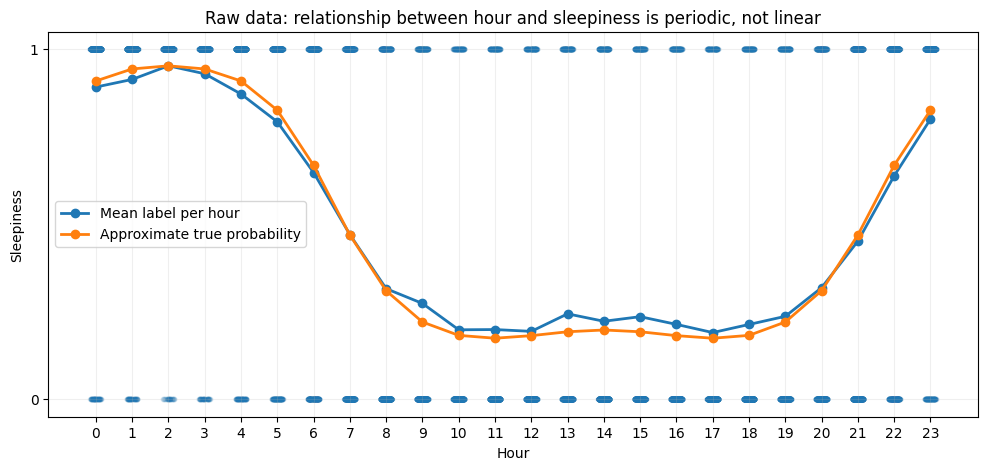

In [34]:
# Calculate the mean label value for each hour (0-23)
hour_mean = np.array([y[h == i].mean() for i in range(24)])

hours_grid = np.arange(24)
true_signal = 1 / (1 + np.exp(-(
    2.2 * np.cos(2 * np.pi * (hours_grid - phase) / 24)
    + 0.8 * np.cos(4 * np.pi * (hours_grid - phase) / 24)
)))

plt.figure(figsize=(12, 5))
plt.scatter(h + np.random.uniform(-0.15, 0.15, size=n), y, alpha=0.08, s=10)
plt.plot(hours_grid, hour_mean, marker='o', linewidth=2, label='Mean label per hour')
plt.plot(hours_grid, true_signal, marker='o', linewidth=2, label='Approximate true probability')
plt.xticks(range(24))
plt.yticks([0, 1])
plt.xlabel("Hour")
plt.ylabel("Sleepiness")
plt.title("Raw data: relationship between hour and sleepiness is periodic, not linear")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [35]:
X_train_raw, X_test_raw, y_train, y_test, h_train, h_test = train_test_split(
    X_raw, y, h, test_size=0.25, random_state=42, stratify=y
)

print(X_train_raw.shape, X_test_raw.shape)

(15000, 1) (5000, 1)


In [36]:
model_raw = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

model_raw.fit(X_train_raw, y_train)

pred_raw = model_raw.predict(X_test_raw)
proba_raw = model_raw.predict_proba(X_test_raw)[:, 1]

print("Raw feature model")
print("Accuracy:", accuracy_score(y_test, pred_raw))
print("ROC AUC:", roc_auc_score(y_test, proba_raw))
print(classification_report(y_test, pred_raw))

Raw feature model
Accuracy: 0.6864
ROC AUC: 0.6982874439300689
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      2636
           1       0.67      0.65      0.66      2364

    accuracy                           0.69      5000
   macro avg       0.69      0.68      0.68      5000
weighted avg       0.69      0.69      0.69      5000



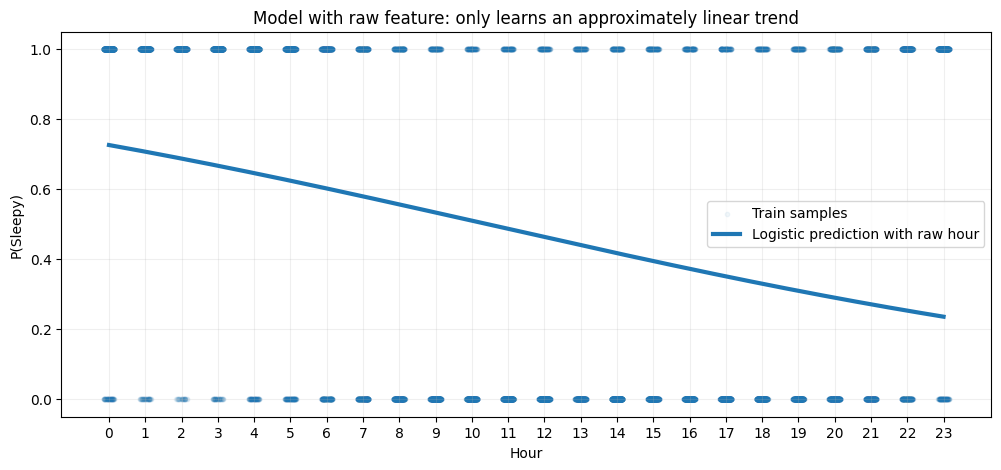

In [37]:
hours_fine = np.linspace(0, 23, 400).reshape(-1, 1)
raw_curve = model_raw.predict_proba(hours_fine)[:, 1]

plt.figure(figsize=(12, 5))
plt.scatter(h_train + np.random.uniform(-0.15, 0.15, size=len(h_train)), y_train, alpha=0.06, s=10, label="Train samples")
plt.plot(hours_fine.ravel(), raw_curve, linewidth=3, label="Logistic prediction with raw hour")
plt.xticks(range(24))
plt.ylim(-0.05, 1.05)
plt.xlabel("Hour")
plt.ylabel("P(Sleepy)")
plt.title("Model with raw feature: only learns an approximately linear trend")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [38]:
def add_cyclical_features(hours):
    hours = np.asarray(hours).reshape(-1)
    x1 = np.sin(2 * np.pi * hours / 24)
    x2 = np.cos(2 * np.pi * hours / 24)
    return np.c_[x1, x2]

X_train_cyc = add_cyclical_features(h_train)
X_test_cyc = add_cyclical_features(h_test)

print(X_train_cyc[:5])

[[-7.07106781e-01  7.07106781e-01]
 [-5.00000000e-01 -8.66025404e-01]
 [ 1.00000000e+00  6.12323400e-17]
 [-9.65925826e-01 -2.58819045e-01]
 [ 7.07106781e-01 -7.07106781e-01]]


In [39]:
model_cyc = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

model_cyc.fit(X_train_cyc, y_train)

pred_cyc = model_cyc.predict(X_test_cyc)
proba_cyc = model_cyc.predict_proba(X_test_cyc)[:, 1]

print("Cyclical feature model")
print("Accuracy:", accuracy_score(y_test, pred_cyc))
print("ROC AUC:", roc_auc_score(y_test, proba_cyc))
print(classification_report(y_test, pred_cyc))

Cyclical feature model
Accuracy: 0.7658
ROC AUC: 0.819175435015367
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      2636
           1       0.76      0.75      0.75      2364

    accuracy                           0.77      5000
   macro avg       0.77      0.76      0.76      5000
weighted avg       0.77      0.77      0.77      5000



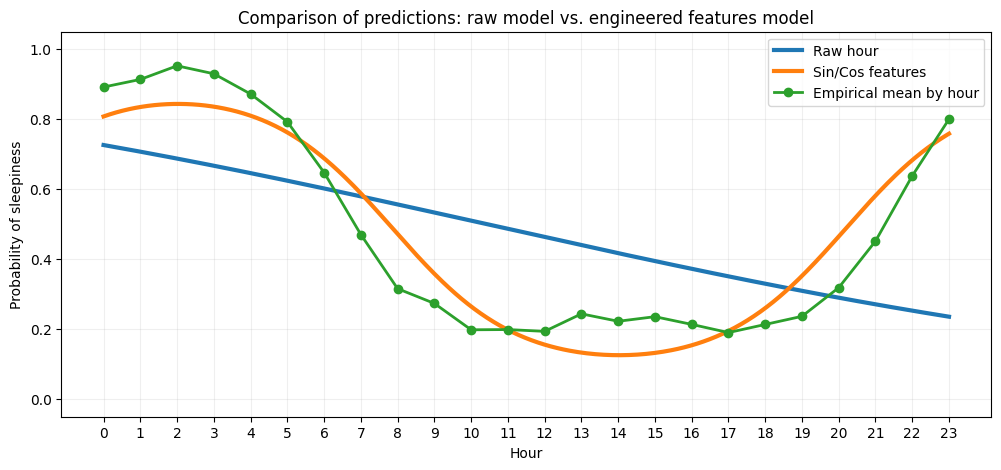

In [40]:
hours_fine = np.linspace(0, 23, 400).reshape(-1, 1)
curve_raw = model_raw.predict_proba(hours_fine)[:, 1]
curve_cyc = model_cyc.predict_proba(add_cyclical_features(hours_fine))[:, 1]

plt.figure(figsize=(12, 5))
plt.plot(hours_fine.ravel(), curve_raw, linewidth=3, label="Raw hour")
plt.plot(hours_fine.ravel(), curve_cyc, linewidth=3, label="Sin/Cos features")
plt.plot(hours_grid, hour_mean, "o-", linewidth=2, label="Empirical mean by hour")
plt.xticks(range(24))
plt.ylim(-0.05, 1.05)
plt.xlabel("Hour")
plt.ylabel("Probability of sleepiness")
plt.title("Comparison of predictions: raw model vs. engineered features model")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

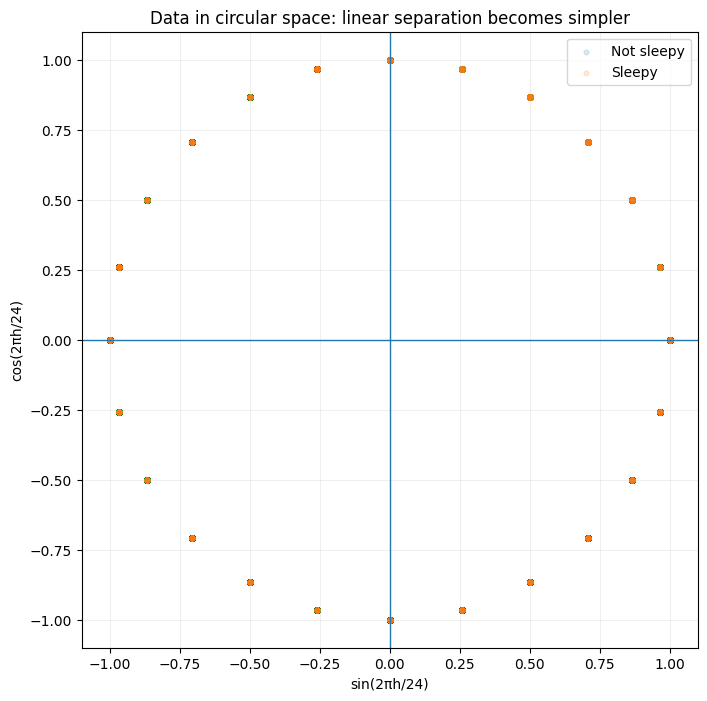

In [41]:
X_all_cyc = add_cyclical_features(h)

plt.figure(figsize=(8, 8))
plt.scatter(X_all_cyc[y == 0, 0], X_all_cyc[y == 0, 1], alpha=0.15, s=12, label="Not sleepy")
plt.scatter(X_all_cyc[y == 1, 0], X_all_cyc[y == 1, 1], alpha=0.15, s=12, label="Sleepy")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.gca().set_aspect("equal", "box")
plt.xlabel("sin(2πh/24)")
plt.ylabel("cos(2πh/24)")
plt.title("Data in circular space: linear separation becomes simpler")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

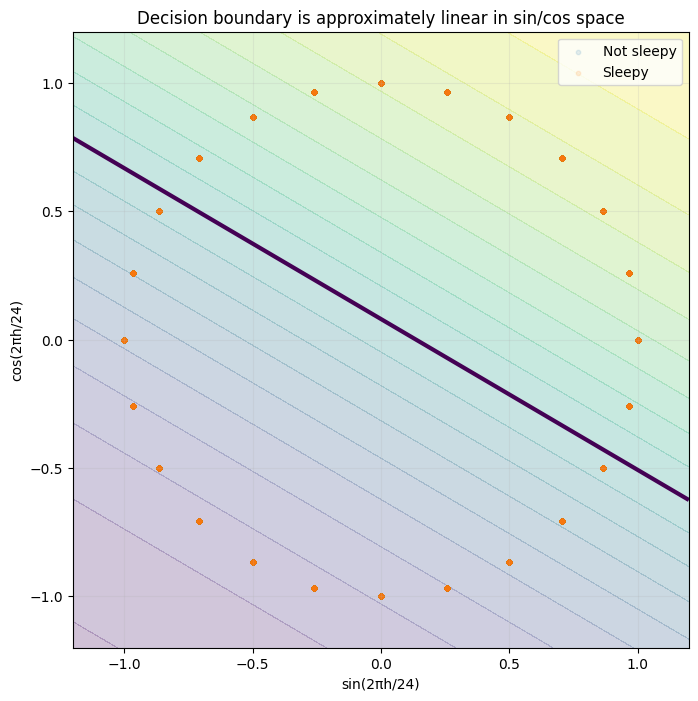

In [42]:
clf = model_cyc.named_steps["clf"]
scaler = model_cyc.named_steps["scaler"]

# Grid of points in sin/cos space
grid = np.linspace(-1.2, 1.2, 300)
xx, yy = np.meshgrid(grid, grid)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Since the model was trained with StandardScaler, we must apply the same scaling
zz = clf.predict_proba(scaler.transform(grid_points))[:, 1].reshape(xx.shape)

plt.figure(figsize=(8, 8))
cs = plt.contour(xx, yy, zz, levels=[0.5], linewidths=3)
plt.contourf(xx, yy, zz, levels=20, alpha=0.25)
plt.scatter(X_all_cyc[y == 0, 0], X_all_cyc[y == 0, 1], alpha=0.12, s=10, label="Not sleepy")
plt.scatter(X_all_cyc[y == 1, 0], X_all_cyc[y == 1, 1], alpha=0.12, s=10, label="Sleepy")
plt.gca().set_aspect("equal", "box")
plt.xlabel("sin(2πh/24)")
plt.ylabel("cos(2πh/24)")
plt.title("Decision boundary is approximately linear in sin/cos space")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

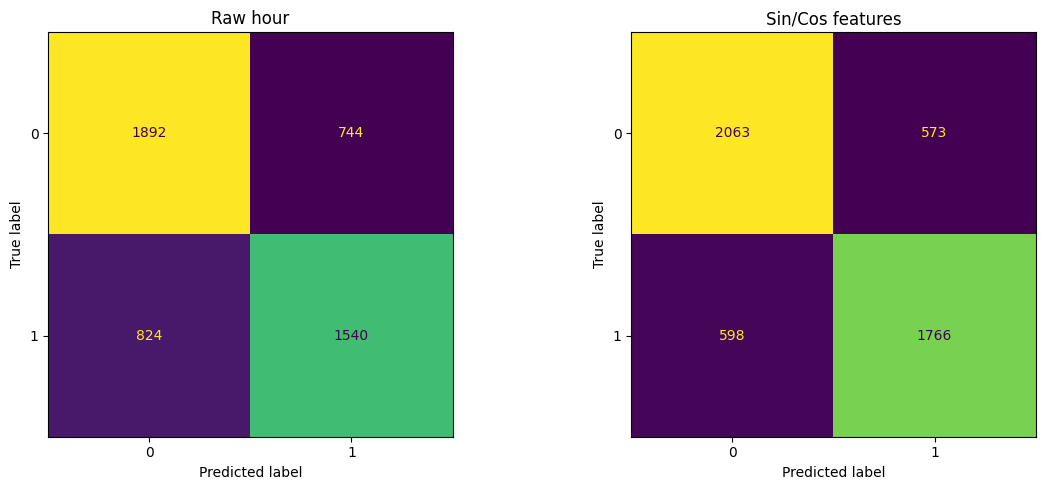

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_raw = confusion_matrix(y_test, pred_raw)
cm_cyc = confusion_matrix(y_test, pred_cyc)

ConfusionMatrixDisplay(cm_raw).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Raw hour")

ConfusionMatrixDisplay(cm_cyc).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Sin/Cos features")

plt.tight_layout()
plt.show()

In [44]:
X_train_h2 = (h_train ** 2).reshape(-1, 1)
X_test_h2 = (h_test ** 2).reshape(-1, 1)

model_h2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

model_h2.fit(X_train_h2, y_train)

pred_h2 = model_h2.predict(X_test_h2)
proba_h2 = model_h2.predict_proba(X_test_h2)[:, 1]

print("h^2 feature model")
print("Accuracy:", accuracy_score(y_test, pred_h2))
print("ROC AUC:", roc_auc_score(y_test, proba_h2))

h^2 feature model
Accuracy: 0.6642
ROC AUC: 0.6982874439300689


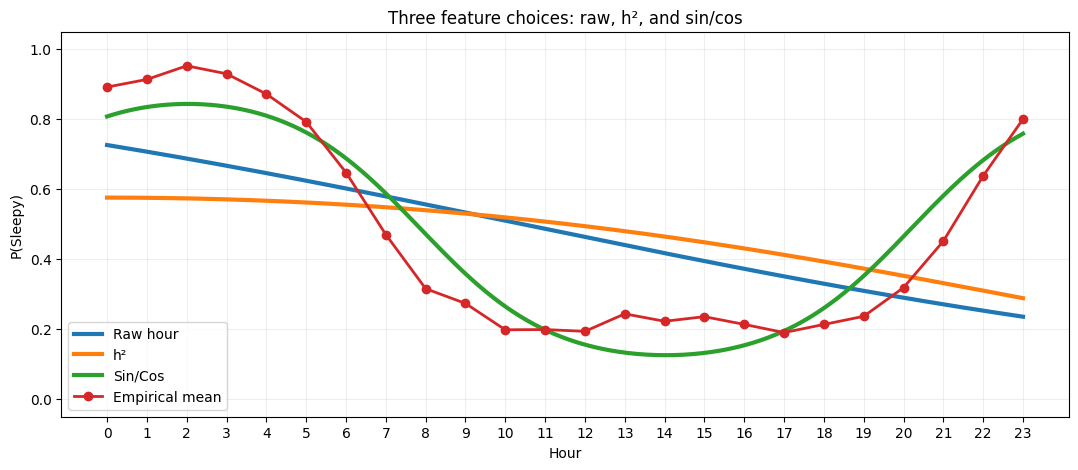

In [45]:
hours_fine = np.linspace(0, 23, 400)

curve_raw = model_raw.predict_proba(hours_fine.reshape(-1, 1))[:, 1]
curve_h2 = model_h2.predict_proba((hours_fine ** 2).reshape(-1, 1))[:, 1]
curve_cyc = model_cyc.predict_proba(add_cyclical_features(hours_fine))[:, 1]

plt.figure(figsize=(13, 5))
plt.plot(hours_fine, curve_raw, linewidth=3, label="Raw hour")
plt.plot(hours_fine, curve_h2, linewidth=3, label="h²")
plt.plot(hours_fine, curve_cyc, linewidth=3, label="Sin/Cos")
plt.plot(hours_grid, hour_mean, "o-", linewidth=2, label="Empirical mean")
plt.xticks(range(24))
plt.ylim(-0.05, 1.05)
plt.xlabel("Hour")
plt.ylabel("P(Sleepy)")
plt.title("Three feature choices: raw, h², and sin/cos")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [46]:
results = {
    "Raw hour": {
        "accuracy": accuracy_score(y_test, pred_raw),
        "roc_auc": roc_auc_score(y_test, proba_raw),
    },
    "h^2": {
        "accuracy": accuracy_score(y_test, pred_h2),
        "roc_auc": roc_auc_score(y_test, proba_h2),
    },
    "Sin/Cos": {
        "accuracy": accuracy_score(y_test, pred_cyc),
        "roc_auc": roc_auc_score(y_test, proba_cyc),
    }
}

for name, vals in results.items():
    print(name, vals)

Raw hour {'accuracy': 0.6864, 'roc_auc': 0.6982874439300689}
h^2 {'accuracy': 0.6642, 'roc_auc': 0.6982874439300689}
Sin/Cos {'accuracy': 0.7658, 'roc_auc': 0.819175435015367}
